In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg  # για την προαιρετική ανάγνωση δικής σας εικόνας

## Άσκηση - Εκθετική εξομάλυνση με αναδρομικό φίλτρο πρώτης τάξης

Τα φίλτρα των προηγούμενων ασκήσεων ήταν μιας κατηγορίας που ονομάζεται **Finite Impulse Response (FIR)**, που πρακτικά σημαίνει ότι η έξοδος εξαρτιόταν μόνο από την είσοδο - χωρις κάποιο αναδρομικό στοιχείο στην εξίσωση διαφορων. Εδώ εξετάζουμε ένα **αναδρομικό** σύστημα διακριτού χρόνου, όπου η έξοδος εξαρτάται και από **προηγούμενες τιμές της εξόδου** - ένα φίλτρο **άπειρης κρουστικής απόκρισης - (IIR)**, γνωστό ως *εκθετική εξομάλυνση* ή *leaky integrator*. Η εξίσωση διαφορών του περιγράφεται ως

$$ y[n] = \alpha\,x[n] + (1-\alpha)\,y[n-1], \qquad 0 < \alpha < 1 \tag{1}$$

Είναι μια **αιτιατή** εξίσωση διαφορών πρώτης τάξης. Μικρό $\alpha$ σημαίνει ισχυρή εξομάλυνση (μεγάλη «μνήμη»), ενώ αν $\alpha\to 1$, το σύστημα αφήνει το σήμα εισόδου σχεδόν αναλλοίωτο.

Η κρουστική του απόκριση δίνεται ως

$$ h[n] = \alpha\,(1-\alpha)^{n} u[n] \tag{2}$$

μια **άπειρη**, εκθετικά φθίνουσα ακολουθία (εξ ου και το όνομα IIR).

### i. Δημιουργία θορυβώδους εικόνας

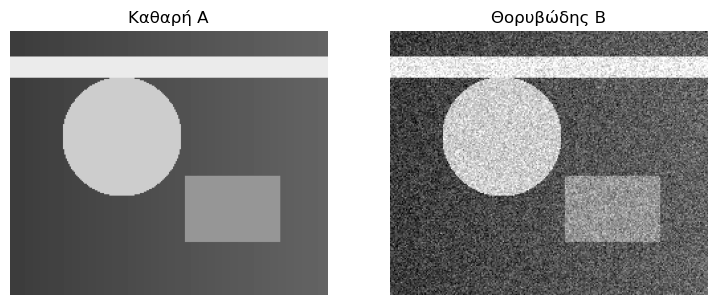

In [2]:
def make_test_image(M=200, N=240):
    """Δημιουργεί μια συνθετική grayscale εικόνα (τιμές 0-255) με ομαλό
    background, φωτεινό δίσκο, ορθογώνιο και λωρίδες (ακμές)."""
    yy, xx = np.mgrid[0:M, 0:N]
    A = 60.0 + 40.0*(xx/N)                       # ομαλή ράμπα φωτεινότητας
    A[(xx-0.35*N)**2 + (yy-0.40*M)**2 < 45**2] = 205   # φωτεινός δίσκος
    A[int(0.55*M):int(0.80*M), int(0.55*N):int(0.85*N)] = 150  # ορθογώνιο
    A[int(0.10*M):int(0.18*M), :] = 235          # οριζόντια λωρίδα
    return np.clip(A, 0, 255)

def add_gaussian_noise(A, sigma=25.0, seed=0):
    rng = np.random.default_rng(seed)
    return np.clip(A + rng.normal(0, sigma, A.shape), 0, 255)

A = make_test_image()
B = add_gaussian_noise(A, sigma=25)

# --- Προαιρετικά: δική σας εικόνα ---
# A = mpimg.imread('./files/MyImage.tif').astype(float)

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(A, cmap='gray', vmin=0, vmax=255); ax[0].set_title('Καθαρή A'); ax[0].axis('off')
ax[1].imshow(B, cmap='gray', vmin=0, vmax=255); ax[1].set_title('Θορυβώδης B'); ax[1].axis('off')
plt.show()

### ii. Φιλτράρισμα κατά γραμμές

Επειδή το φίλτρο είναι **αναδρομικό**, δεν διατρέχουμε τριάδες: κρατάμε την προηγούμενη έξοδο και τη χρησιμοποιούμε για κάθε νέο $n$. Αρχικοποιούμε με $y[0]=x[0]$ (κάθε γραμμή ξεκινά «καθαρά»).

    M, N = B.shape
    C = np.zeros((M, N))
    a = 0.4
    for i in range(M):
        C[i, 0] = B[i, 0]                 # αρχική συνθήκη
        for j in range(1, N):
            C[i, j] = #################   # Σχέση (1)

**Αιτιατό πέρασμα κατά γραμμές** (αριστερά → δεξιά)

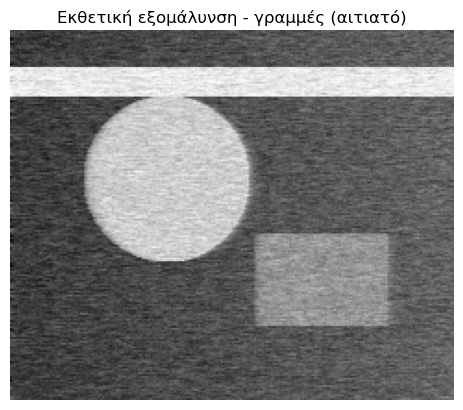

In [3]:
M, N = B.shape
a = 0.4
C = np.zeros((M, N))

for i in range(M):
    C[i, 0] = B[i, 0]
    for j in range(1, N):
        C[i, j] = a*B[i, j] + (1-a)*C[i, j-1]

C = np.clip(C, 0, 255).astype(np.uint8)
plt.figure()
plt.imshow(C, cmap=plt.get_cmap('gray'), vmin=0, vmax=255)
plt.title('Εκθετική εξομάλυνση - γραμμές (αιτιατό)')
plt.axis('off')
plt.show()

**Αιτιατό πέρασμα κατά στήλες** (πάνω → κάτω)

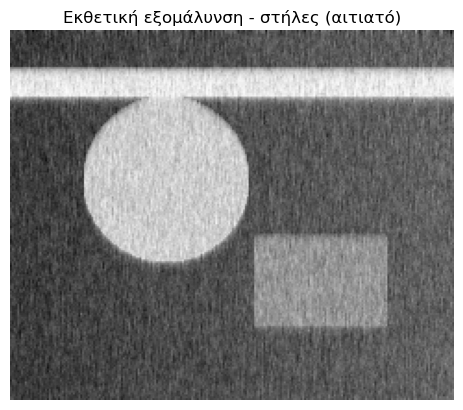

In [4]:
C = np.zeros((M, N))
for j in range(N):
    C[0, j] = B[0, j]
    for i in range(1, M):
        C[i, j] = a*B[i, j] + (1-a)*C[i-1, j]

C = np.clip(C, 0, 255).astype(np.uint8)
plt.figure()
plt.imshow(C, cmap=plt.get_cmap('gray'), vmin=0, vmax=255)
plt.title('Εκθετική εξομάλυνση - στήλες (αιτιατό)')
plt.axis('off')
plt.show()

### iii. Επίδραση του $\alpha$

Μικρότερο $\alpha$ → ισχυρότερη εξομάλυνση αλλά και μεγαλύτερη καθυστέρηση/θόλωση.

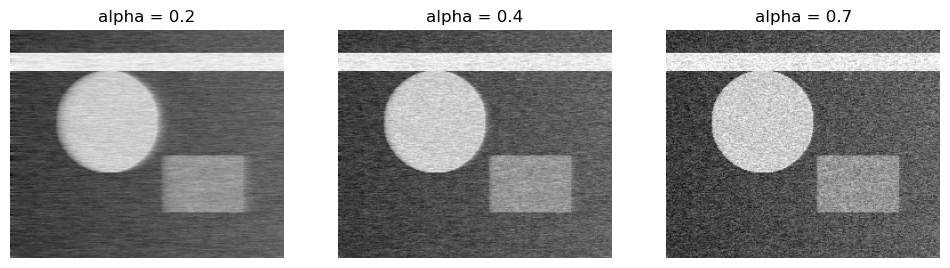

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for k, a in enumerate([0.2, 0.4, 0.7]):
    C = np.zeros((M, N))
    for i in range(M):
        C[i, 0] = B[i, 0]
        for j in range(1, N):
            C[i, j] = a*B[i, j] + (1-a)*C[i, j-1]
    ax[k].imshow(np.clip(C,0,255).astype(np.uint8), cmap='gray', vmin=0, vmax=255)
    ax[k].set_title(f'alpha = {a}'); ax[k].axis('off')
plt.show()

### iv. Μηδενικής φάσης εξομάλυνση (εμπρός + πίσω πέρασμα)

Δεν μπορείτε ακόμα να το δείτε αλλά η μη-γραμμική φάση του IIR προκαλεί ολίσθηση των ακμών προς την κατεύθυνση σάρωσης (φαινόμενο «ουράς κομήτη»). Αυτό μπορεί να εξουδετερωθεί "τρέχοντας" το φίλτρο **εμπρός και μετά ανάποδα** (τεχνική τύπου *filtfilt*, την οποία θα δείτε αναλυτικά σε άσκηση επόμενου Κεφαλαίου): οι δύο καθυστερήσεις αλληλοαναιρούνται και το συνολικό φίλτρο γίνεται **μηδενικής φάσης**.

Ας εφαρμόσουμε αυτήν την τεχνική.

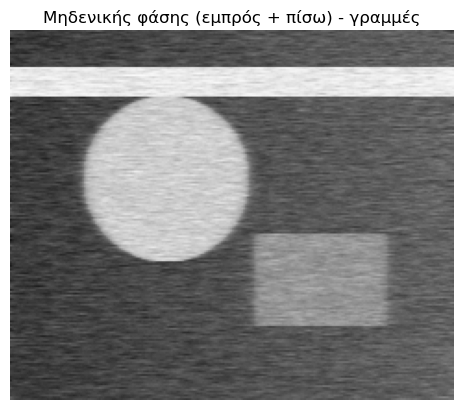

In [6]:
a = 0.4
# εμπρός κατά γραμμές
F = np.zeros((M, N))
for i in range(M):
    F[i, 0] = B[i, 0]
    for j in range(1, N):
        F[i, j] = a*B[i, j] + (1-a)*F[i, j-1]
# πίσω κατά γραμμές (πάνω στο F)
G = np.zeros((M, N))
for i in range(M):
    G[i, N-1] = F[i, N-1]
    for j in range(N-2, -1, -1):
        G[i, j] = a*F[i, j] + (1-a)*G[i, j+1]

C = np.clip(G, 0, 255).astype(np.uint8)
plt.figure()
plt.imshow(C, cmap=plt.get_cmap('gray'), vmin=0, vmax=255)
plt.title('Μηδενικής φάσης (εμπρός + πίσω) - γραμμές')
plt.axis('off')
plt.show()

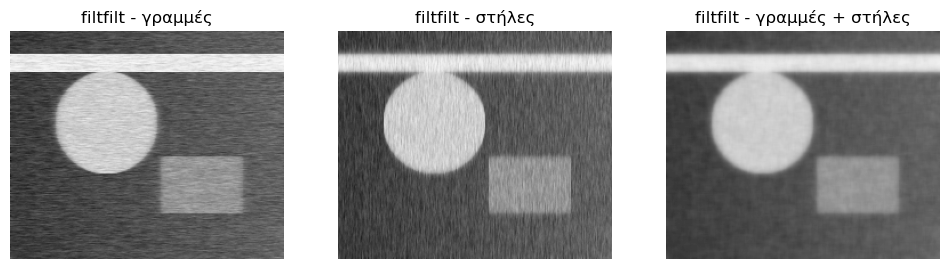

In [7]:
a = 0.4

# --- Βοηθητικές συναρτήσεις μηδενικής φάσης (εμπρός + πίσω πέρασμα) ---
def filtfilt_rows(X, a):
    """Εμπρός+πίσω αιτιατό πέρασμα ΚΑΤΑ ΓΡΑΜΜΕΣ (μηδενική φάση οριζόντια)."""
    M, N = X.shape
    F = np.zeros((M, N))                       # εμπρός: αριστερά -> δεξιά
    for i in range(M):
        F[i, 0] = X[i, 0]
        for j in range(1, N):
            F[i, j] = a*X[i, j] + (1-a)*F[i, j-1]
    G = np.zeros((M, N))                       # πίσω: δεξιά -> αριστερά
    for i in range(M):
        G[i, N-1] = F[i, N-1]
        for j in range(N-2, -1, -1):
            G[i, j] = a*F[i, j] + (1-a)*G[i, j+1]
    return G

def filtfilt_cols(X, a):
    """Εμπρός+πίσω αιτιατό πέρασμα ΚΑΤΑ ΣΤΗΛΕΣ (μηδενική φάση κατακόρυφα)."""
    M, N = X.shape
    F = np.zeros((M, N))                       # εμπρός: πάνω -> κάτω
    for j in range(N):
        F[0, j] = X[0, j]
        for i in range(1, M):
            F[i, j] = a*X[i, j] + (1-a)*F[i-1, j]
    G = np.zeros((M, N))                       # πίσω: κάτω -> πάνω
    for j in range(N):
        G[M-1, j] = F[M-1, j]
        for i in range(M-2, -1, -1):
            G[i, j] = a*F[i, j] + (1-a)*G[i+1, j]
    return G

# 1) Μόνο γραμμές  2) Μόνο στήλες  3) Γραμμές ΚΑΙ στήλες (διαχωρίσιμο 2-D)
R  = filtfilt_rows(B, a)                       # μηδενική φάση οριζόντια
Cc = filtfilt_cols(B, a)                       # μηδενική φάση κατακόρυφα
RC = filtfilt_cols(filtfilt_rows(B, a), a)     # μηδενική φάση και στις δύο διευθύνσεις

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(np.clip(R,  0, 255).astype(np.uint8), cmap='gray', vmin=0, vmax=255)
ax[0].set_title('filtfilt - γραμμές');            ax[0].axis('off')
ax[1].imshow(np.clip(Cc, 0, 255).astype(np.uint8), cmap='gray', vmin=0, vmax=255)
ax[1].set_title('filtfilt - στήλες');             ax[1].axis('off')
ax[2].imshow(np.clip(RC, 0, 255).astype(np.uint8), cmap='gray', vmin=0, vmax=255)
ax[2].set_title('filtfilt - γραμμές + στήλες');   ax[2].axis('off')
plt.show()

### Παρατηρήσεις

Το αναδρομικό φίλτρο πρώτης τάξης εξομαλύνει αποδοτικά τον Gaussian θόρυβο με ελάχιστο υπολογιστικό κόστος (μία πρόσθεση και ένας πολλαπλασιασμός ανά pixel), χωρίς να χρειάζεται αποθήκευση παραθύρου - γι' αυτό προτιμάται σε καταστάσεις real time. Το τίμημα είναι η **μη-γραμμική φάση**: το μονόδρομο πέρασμα «σέρνει» τις ακμές προς την κατεύθυνση σάρωσης (ορατή ασυμμετρία κατά γραμμές ή στήλες). 

Η τιμή του $\alpha$ ρυθμίζει τον συμβιβασμό θορύβου–ευκρίνειας: μικρό $\alpha$ καθαρίζει περισσότερο αλλά θολώνει. Το διπλό πέρασμα (εμπρός + πίσω) εξαλείφει την ολίσθηση και δίνει συμμετρικό, μηδενικής φάσης αποτέλεσμα, με ουσιαστικά διπλάσια "τάξη" φιλτραρίσματος. Σε σχέση με τα φίλτρα των υπολοίπων ασκήσεων του Κεφαλαίου, το φίλτρο IIR αυτό πετυχαίνει ισχυρότερη εξομάλυνση με λιγότερες πράξεις, αλλά απαιτεί προσοχή στην αιτιατότητα και στις αρχικές συνθήκες.

---
---